# 05 Network EDA

In [1]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
BC_DATA_DIR = PROJECT_ROOT / 'outputs' / '04_bibliographic_coupling_network' / 'data'
COCIT_DATA_DIR = PROJECT_ROOT / 'outputs' / '03_cocitation_network' / 'data'
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / '05_network_eda'
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / 'figures'
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / 'tables'
DATA_OUTPUT_DIR = NOTEBOOK_OUTPUT_DIR / 'data'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GENDER_CATEGORIES = ['MM', 'MW', 'WM', 'WW']
PLOT_SAMPLE_PER_GENDER = 50000
RANDOM_STATE = 42

## 0. Helper Functions

In [3]:
def save_table(df, filename, index=True):
    path = TABLE_DIR / filename
    df.to_csv(path, index=index)
    return path

def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    return path

def standardize_citation_edges(edges):
    out = edges.rename(columns={'citing_paper_id': 'citing', 'cited_paper_id': 'cited'})[['citing', 'cited']].copy()
    out['citing'] = out['citing'].astype(str)
    out['cited'] = out['cited'].astype(str)
    return out

def standardize_undirected_network(net, representation):
    if representation == 'bibliographic_coupling':
        out = net[['paper_i', 'paper_j', 'shared_references', 'jaccard_reference_sets']].rename(columns={'shared_references': 'weight', 'jaccard_reference_sets': 'jaccard'}).copy()
    else:
        out = net[['paper_a', 'paper_b', 'shared_citers', 'jaccard']].rename(columns={'paper_a': 'paper_i', 'paper_b': 'paper_j', 'shared_citers': 'weight'}).copy()
    out['paper_i'] = out['paper_i'].astype(str)
    out['paper_j'] = out['paper_j'].astype(str)
    out['weight'] = pd.to_numeric(out['weight'], errors='coerce')
    out['jaccard'] = pd.to_numeric(out['jaccard'], errors='coerce')
    out = out[out['paper_i'].ne(out['paper_j']) & out['weight'].gt(0)].copy()
    lo = out[['paper_i', 'paper_j']].min(axis=1)
    hi = out[['paper_i', 'paper_j']].max(axis=1)
    out['paper_i'] = lo
    out['paper_j'] = hi
    return out.sort_values(['weight', 'jaccard'], ascending=False).drop_duplicates(['paper_i', 'paper_j']).reset_index(drop=True)

def gini(values):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    if len(x) == 0 or x.sum() == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    cumulative = np.cumsum(x)
    return (n + 1 - 2 * (cumulative.sum() / cumulative[-1])) / n

def top_share(values, fraction):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    total = x.sum()
    if len(x) == 0 or total == 0:
        return np.nan
    k = max(1, int(np.ceil(len(x) * fraction)))
    return np.partition(x, len(x) - k)[-k:].sum() / total

def count_distribution_summary(values):
    s = pd.Series(values).dropna().astype(float)
    mean = s.mean()
    variance = s.var()
    return pd.Series({'n': len(s), 'mean': mean, 'variance': variance, 'variance_to_mean': variance / mean if mean > 0 else np.nan, 'median': s.median(), 'p75': s.quantile(0.75), 'p90': s.quantile(0.9), 'p95': s.quantile(0.95), 'p99': s.quantile(0.99), 'max': s.max(), 'uncited_share': (s == 0).mean(), 'gini': gini(s.values), 'top_1pct_citation_share': top_share(s.values, 0.01), 'top_5pct_citation_share': top_share(s.values, 0.05), 'top_10pct_citation_share': top_share(s.values, 0.1)})

def citation_summary_by_gender(df, citation_col):
    rows = []
    for gender in GENDER_CATEGORIES:
        x = df.loc[df['gender_cat'].eq(gender), citation_col].astype(float)
        row = count_distribution_summary(x)
        row['gender_cat'] = gender
        row['total_citations'] = x.sum()
        rows.append(row)
    out = pd.DataFrame(rows).set_index('gender_cat')
    total_citations = out['total_citations'].sum()
    out['citation_share'] = out['total_citations'] / total_citations if total_citations > 0 else np.nan
    return out

def sampled_by_gender(df, n_per_group=PLOT_SAMPLE_PER_GENDER):
    parts = []
    for gender in GENDER_CATEGORIES:
        g = df[df['gender_cat'].eq(gender)]
        if len(g) == 0:
            continue
        n = min(len(g), n_per_group)
        parts.append(g.sample(n=n, random_state=RANDOM_STATE))
    if not parts:
        return df.iloc[0:0].copy()
    return pd.concat(parts, ignore_index=True)

def ccdf_from_counts(values):
    s = pd.Series(values).dropna().astype(int)
    vc = s.value_counts().sort_index()
    ccdf = vc.iloc[::-1].cumsum().iloc[::-1] / len(s)
    return pd.DataFrame({'x': vc.index.astype(int), 'ccdf': ccdf.values})

def network_node_features(edges, prefix):
    forward = edges[['paper_i', 'paper_j', 'weight']].rename(columns={'paper_i': 'paper_id', 'paper_j': 'neighbor_id'})
    reverse = edges[['paper_i', 'paper_j', 'weight']].rename(columns={'paper_j': 'paper_id', 'paper_i': 'neighbor_id'})
    long_edges = pd.concat([forward, reverse], ignore_index=True)
    features = long_edges.groupby('paper_id', sort=False).agg(degree=('neighbor_id', 'nunique'), strength=('weight', 'sum'), mean_weight=('weight', 'mean'), max_weight=('weight', 'max')).reset_index()
    features = features.rename(columns={'degree': f'{prefix}_degree', 'strength': f'{prefix}_strength', 'mean_weight': f'{prefix}_mean_weight', 'max_weight': f'{prefix}_max_weight'})
    del long_edges, forward, reverse
    gc.collect()
    return features

def heatmap_from_matrix(matrix, title, xlabel, ylabel, filename, fmt='.2f'):
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(matrix.values, aspect='auto')
    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if matrix.shape[0] <= 12 and matrix.shape[1] <= 12:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                value = matrix.iloc[i, j]
                if pd.notna(value):
                    ax.text(j, i, format(value, fmt), ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax)
    save_figure(filename)

## Load Final Data and Citation-Derived Networks

In [4]:
papers = pd.read_pickle(PROCESSED_DIR / 'papers_final.pkl')
cs_papers = pd.read_pickle(PROCESSED_DIR / 'cs_papers_final.pkl')
edges_final = standardize_citation_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_final.pkl'))
edges_all_to_cs = standardize_citation_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_all_to_cs_final.pkl'))
edges_cs_to_cs = standardize_citation_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_cs_to_cs_final.pkl'))
papers['id'] = papers['id'].astype(str)
cs_papers['id'] = cs_papers['id'].astype(str)
print('Final papers:', papers.shape)
print('Final CS papers:', cs_papers.shape)
print('Final direct edges:', edges_final.shape)
print('Final All→CS edges:', edges_all_to_cs.shape)
print('Final CS→CS edges:', edges_cs_to_cs.shape)

Final papers: (3026412, 29)
Final CS papers: (1542691, 29)
Final direct edges: (18904534, 2)
Final All→CS edges: (11601416, 2)
Final CS→CS edges: (9413932, 2)


In [5]:
bib_raw = pd.read_pickle(BC_DATA_DIR / 'net_bib_coupling_topk.pkl')
cocit_raw = pd.read_feather(COCIT_DATA_DIR / 'cocitation_edges.feather')
bib_edges = standardize_undirected_network(bib_raw, representation='bibliographic_coupling')
cocit_edges = standardize_undirected_network(cocit_raw, representation='cocitation')
del bib_raw, cocit_raw
gc.collect()
print('Bibliographic-coupling edges:', bib_edges.shape)
print('Co-citation edges:', cocit_edges.shape)

Bibliographic-coupling edges: (3934046, 4)
Co-citation edges: (232065, 4)


# 5.4 Direct Citation Structure
## 5.4.1 Direct Citation Network Size and Degree Distributions

In [6]:
out_degree = edges_final.groupby('citing', sort=False).size()
in_degree = edges_final.groupby('cited', sort=False).size()
direct_degree_df = papers[['id', 'year', 'decade', 'primary_field', 'first_last_cat', 'n_refs']].copy()
direct_degree_df['out_degree'] = direct_degree_df['id'].map(out_degree).fillna(0).astype('int64')
direct_degree_df['in_degree'] = direct_degree_df['id'].map(in_degree).fillna(0).astype('int64')
n_nodes = len(direct_degree_df)
n_edges = len(edges_final)
direct_network_summary = pd.Series({'n_nodes': n_nodes, 'n_edges': n_edges, 'n_unique_citing_nodes': edges_final['citing'].nunique(), 'n_unique_cited_nodes': edges_final['cited'].nunique(), 'directed_density': n_edges / (n_nodes * (n_nodes - 1)), 'share_zero_in_degree': (direct_degree_df['in_degree'] == 0).mean(), 'share_zero_out_degree': (direct_degree_df['out_degree'] == 0).mean(), 'mean_in_degree': direct_degree_df['in_degree'].mean(), 'median_in_degree': direct_degree_df['in_degree'].median(), 'mean_out_degree': direct_degree_df['out_degree'].mean(), 'median_out_degree': direct_degree_df['out_degree'].median(), 'self_edges_after_filtering': int(edges_final['citing'].eq(edges_final['cited']).sum())})
display(direct_network_summary.to_frame('value'))
save_table(direct_network_summary.to_frame('value'), 'direct_network_summary.csv')

,value
n_nodes,3.026412e+06
n_edges,1.890453e+07
n_unique_citing_nodes,2.733997e+06
n_unique_cited_nodes,1.915670e+06
directed_density,2.064002e-06
share_zero_in_degree,3.670161e-01
share_zero_out_degree,9.662102e-02
mean_in_degree,6.246517e+00
median_in_degree,1.000000e+00
mean_out_degree,6.246517e+00


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/direct_network_summary.csv')

In [7]:
degree_quantiles = pd.DataFrame({'in_degree': direct_degree_df['in_degree'].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0]), 'out_degree': direct_degree_df['out_degree'].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0])})
degree_quantiles.index.name = 'quantile'
display(degree_quantiles)
save_table(degree_quantiles, 'direct_degree_quantiles.csv')

,in_degree,out_degree
quantile,,
0.000,0.0,0.0
0.250,0.0,2.0
0.500,1.0,5.0
0.750,4.0,9.0
0.900,12.0,14.0
0.950,23.0,18.0
0.990,78.0,28.0
0.999,359.0,59.0
1.000,48576.0,1090.0


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/direct_degree_quantiles.csv')

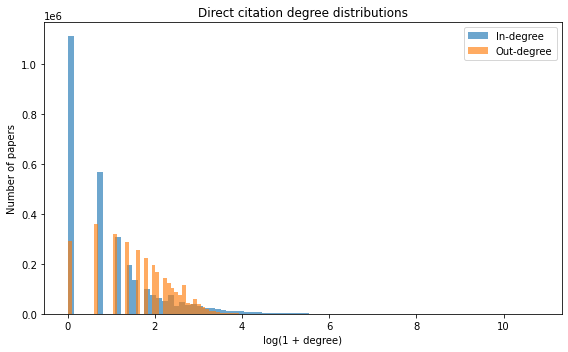

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/direct_degree_log1p_histogram.png')

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(direct_degree_df['in_degree']), bins=80, alpha=0.65, label='In-degree')
plt.hist(np.log1p(direct_degree_df['out_degree']), bins=80, alpha=0.65, label='Out-degree')
plt.xlabel('log(1 + degree)')
plt.ylabel('Number of papers')
plt.title('Direct citation degree distributions')
plt.legend()
save_figure('direct_degree_log1p_histogram.png')

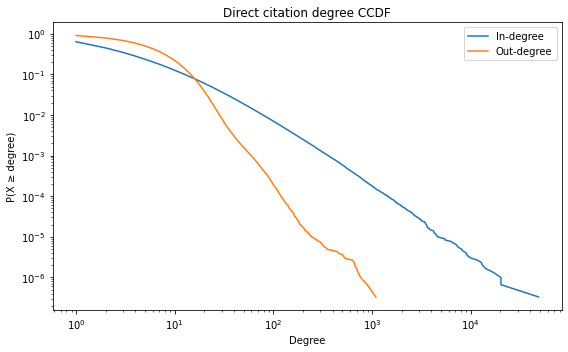

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/direct_degree_ccdf_loglog.png')

In [9]:
plt.figure(figsize=(8, 5))
for col, label in [('in_degree', 'In-degree'), ('out_degree', 'Out-degree')]:
    ccdf = ccdf_from_counts(direct_degree_df[col])
    ccdf = ccdf[ccdf['x'] > 0]
    plt.loglog(ccdf['x'], ccdf['ccdf'], label=label)
plt.xlabel('Degree')
plt.ylabel('P(X ≥ degree)')
plt.title('Direct citation degree CCDF')
plt.legend()
save_figure('direct_degree_ccdf_loglog.png')

## 5.4.2 Citation Reception by Gender Category

In [10]:
cs_known = cs_papers[cs_papers['first_last_cat'].isin(GENDER_CATEGORIES)][['id', 'first_last_cat', 'year', 'decade', 'primary_subfield', 'primary_topic_name', 'venue_rank_clean', 'n_refs']].rename(columns={'id': 'paper_id', 'first_last_cat': 'gender_cat'}).copy()
all_to_cs_counts = edges_all_to_cs['cited'].value_counts()
cs_to_cs_counts = edges_cs_to_cs['cited'].value_counts()
cs_known['citations_all_to_cs'] = cs_known['paper_id'].map(all_to_cs_counts).fillna(0).astype('int64')
cs_known['citations_cs_to_cs'] = cs_known['paper_id'].map(cs_to_cs_counts).fillna(0).astype('int64')
print('Known-gender CS papers:', len(cs_known))
display(cs_known.head())

Known-gender CS papers: 1081363


,paper_id,gender_cat,year,decade,primary_subfield,primary_topic_name,venue_rank_clean,n_refs,citations_all_to_cs,citations_cs_to_cs
4,W2462075127,WM,2016,2010,Artificial Intelligence,Semantic Web and Ontology Development,N/A,2,0,0
9,W2625066686,MM,2011,2010,Artificial Intelligence,Statistical Machine Translation and Natural La...,N/A,8,4,4
14,W2176955128,MM,2011,2010,Artificial Intelligence,Statistical Machine Translation and Natural La...,B,14,0,0
16,W2735801072,WM,2011,2010,Information Systems,QoS-Aware Web Services Composition and Semanti...,N/A,6,0,0
17,W2250869396,WM,2012,2010,Artificial Intelligence,Statistical Machine Translation and Natural La...,C,11,0,0


In [11]:
reception_all_to_cs = citation_summary_by_gender(cs_known, 'citations_all_to_cs')
reception_cs_to_cs = citation_summary_by_gender(cs_known, 'citations_cs_to_cs')
display(reception_all_to_cs)
display(reception_cs_to_cs)
save_table(reception_all_to_cs, 'citation_reception_by_gender_all_to_cs.csv')
save_table(reception_cs_to_cs, 'citation_reception_by_gender_cs_to_cs.csv')

,n,mean,variance,variance_to_mean,median,p75,p90,p95,p99,max,uncited_share,gini,top_1pct_citation_share,top_5pct_citation_share,top_10pct_citation_share,total_citations,citation_share
gender_cat,,,,,,,,,,,,,,,,,
MM,790617.0,8.781310,7823.099301,890.880662,1.0,5.0,16.0,31.0,111.0,48576.0,0.334085,0.836659,0.371371,0.617350,0.741917,6942653.0,0.799271
MW,97399.0,6.585643,1039.858081,157.897741,1.0,4.0,13.0,25.0,84.0,2598.0,0.366852,0.822332,0.320279,0.579019,0.715189,641435.0,0.073845
WM,137756.0,5.898320,1942.716873,329.367820,1.0,4.0,12.0,22.0,73.0,10084.0,0.374612,0.817789,0.318462,0.570541,0.706632,812529.0,0.093542
WW,55591.0,5.209836,675.160411,129.593407,1.0,4.0,10.0,20.0,66.0,2417.0,0.392815,0.820800,0.315154,0.574456,0.711795,289620.0,0.033342


,n,mean,variance,variance_to_mean,median,p75,p90,p95,p99,max,uncited_share,gini,top_1pct_citation_share,top_5pct_citation_share,top_10pct_citation_share,total_citations,citation_share
gender_cat,,,,,,,,,,,,,,,,,
MM,790617.0,7.085504,3849.628298,543.310432,1.0,4.0,13.0,26.0,93.0,32374.0,0.390637,0.844628,0.366516,0.621853,0.749627,5601920.0,0.797597
MW,97399.0,5.431493,754.565316,138.924104,1.0,3.0,11.0,21.0,73.0,1935.0,0.424932,0.836874,0.333614,0.597274,0.733060,529022.0,0.075322
WM,137756.0,4.807050,1131.848611,235.455961,1.0,3.0,10.0,18.0,62.0,8075.0,0.434057,0.832008,0.327268,0.586447,0.723322,662200.0,0.094283
WW,55591.0,4.143800,461.204577,111.299906,1.0,3.0,8.0,16.0,56.0,2172.0,0.461675,0.837825,0.328285,0.594831,0.731861,230358.0,0.032798


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/citation_reception_by_gender_cs_to_cs.csv')

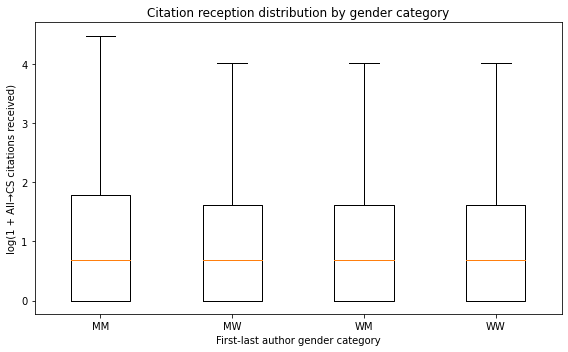

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/citation_reception_gender_boxplot_all_to_cs.png')

In [12]:
plot_sample = sampled_by_gender(cs_known[['gender_cat', 'citations_all_to_cs', 'citations_cs_to_cs']])
data = [np.log1p(plot_sample.loc[plot_sample['gender_cat'].eq(g), 'citations_all_to_cs']) for g in GENDER_CATEGORIES]
plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=GENDER_CATEGORIES, showfliers=False)
plt.xlabel('First-last author gender category')
plt.ylabel('log(1 + All→CS citations received)')
plt.title('Citation reception distribution by gender category')
save_figure('citation_reception_gender_boxplot_all_to_cs.png')

,paper_share,all_to_cs_citation_share,cs_to_cs_citation_share
MM,0.731130,0.799271,0.797597
MW,0.090071,0.073845,0.075322
WM,0.127391,0.093542,0.094283
WW,0.051408,0.033342,0.032798


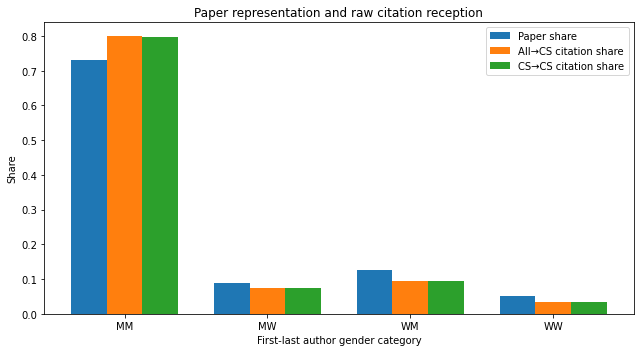

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/paper_vs_raw_citation_share_by_gender.png')

In [13]:
gender_paper_counts = cs_known['gender_cat'].value_counts().reindex(GENDER_CATEGORIES)
gender_paper_share = gender_paper_counts / gender_paper_counts.sum()
descriptive_share_table = pd.DataFrame({'paper_share': gender_paper_share, 'all_to_cs_citation_share': reception_all_to_cs['citation_share'], 'cs_to_cs_citation_share': reception_cs_to_cs['citation_share']})
display(descriptive_share_table)
save_table(descriptive_share_table, 'paper_and_raw_citation_shares_by_gender.csv')
x = np.arange(len(GENDER_CATEGORIES))
width = 0.25
plt.figure(figsize=(9, 5))
plt.bar(x - width, descriptive_share_table['paper_share'], width, label='Paper share')
plt.bar(x, descriptive_share_table['all_to_cs_citation_share'], width, label='All→CS citation share')
plt.bar(x + width, descriptive_share_table['cs_to_cs_citation_share'], width, label='CS→CS citation share')
plt.xticks(x, GENDER_CATEGORIES)
plt.ylabel('Share')
plt.xlabel('First-last author gender category')
plt.title('Paper representation and raw citation reception')
plt.legend()
save_figure('paper_vs_raw_citation_share_by_gender.png')

## 5.4.3 Uncited Papers and Heavy-Tailed Citation Outcomes

In [14]:
heavy_tail_summary = pd.concat({'All→CS': count_distribution_summary(cs_known['citations_all_to_cs']), 'CS→CS': count_distribution_summary(cs_known['citations_cs_to_cs'])}, axis=1).T
display(heavy_tail_summary)
save_table(heavy_tail_summary, 'citation_heavy_tail_summary.csv')

,n,mean,variance,variance_to_mean,median,p75,p90,p95,p99,max,uncited_share,gini,top_1pct_citation_share,top_5pct_citation_share,top_10pct_citation_share
All→CS,1081363.0,8.032675,6097.140706,759.042421,1.0,5.0,15.0,29.0,102.0,48576.0,0.345218,0.834263,0.363154,0.610608,0.737073
CS→CS,1081363.0,6.495044,3051.441331,469.810743,1.0,4.0,12.0,24.0,86.0,32374.0,0.402909,0.843663,0.361468,0.617808,0.746895


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/citation_heavy_tail_summary.csv')

,All→CS,CS→CS
gender_cat,,
MM,0.334085,0.390637
MW,0.366852,0.424932
WM,0.374612,0.434057
WW,0.392815,0.461675


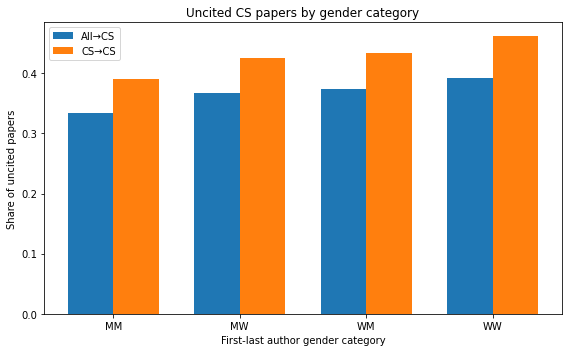

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/uncited_share_by_gender.png')

In [15]:
uncited_by_gender = pd.DataFrame({'All→CS': cs_known.groupby('gender_cat')['citations_all_to_cs'].apply(lambda s: (s == 0).mean()).reindex(GENDER_CATEGORIES), 'CS→CS': cs_known.groupby('gender_cat')['citations_cs_to_cs'].apply(lambda s: (s == 0).mean()).reindex(GENDER_CATEGORIES)})
display(uncited_by_gender)
save_table(uncited_by_gender, 'uncited_share_by_gender.csv')
x = np.arange(len(GENDER_CATEGORIES))
width = 0.36
plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, uncited_by_gender['All→CS'], width, label='All→CS')
plt.bar(x + width / 2, uncited_by_gender['CS→CS'], width, label='CS→CS')
plt.xticks(x, GENDER_CATEGORIES)
plt.ylabel('Share of uncited papers')
plt.xlabel('First-last author gender category')
plt.title('Uncited CS papers by gender category')
plt.legend()
save_figure('uncited_share_by_gender.png')

In [16]:
concentration_rows = []
for gender in GENDER_CATEGORIES:
    x = cs_known.loc[cs_known['gender_cat'].eq(gender), 'citations_all_to_cs']
    concentration_rows.append({'gender_cat': gender, 'gini': gini(x.values), 'top_1pct_citation_share': top_share(x.values, 0.01), 'top_5pct_citation_share': top_share(x.values, 0.05), 'top_10pct_citation_share': top_share(x.values, 0.1)})
citation_concentration_by_gender = pd.DataFrame(concentration_rows).set_index('gender_cat')
display(citation_concentration_by_gender)
save_table(citation_concentration_by_gender, 'citation_concentration_by_gender_all_to_cs.csv')

,gini,top_1pct_citation_share,top_5pct_citation_share,top_10pct_citation_share
gender_cat,,,,
MM,0.836659,0.371371,0.617350,0.741917
MW,0.822332,0.320279,0.579019,0.715189
WM,0.817789,0.318462,0.570541,0.706632
WW,0.820800,0.315154,0.574456,0.711795


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/citation_concentration_by_gender_all_to_cs.csv')

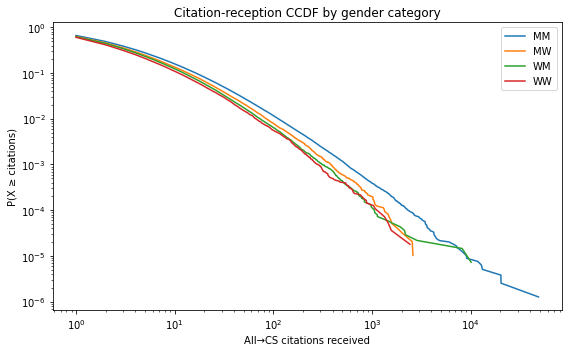

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/citation_reception_ccdf_by_gender.png')

In [17]:
plt.figure(figsize=(8, 5))
for gender in GENDER_CATEGORIES:
    x = cs_known.loc[cs_known['gender_cat'].eq(gender), 'citations_all_to_cs']
    ccdf = ccdf_from_counts(x)
    ccdf = ccdf[ccdf['x'] > 0]
    plt.loglog(ccdf['x'], ccdf['ccdf'], label=gender)
plt.xlabel('All→CS citations received')
plt.ylabel('P(X ≥ citations)')
plt.title('Citation-reception CCDF by gender category')
plt.legend()
save_figure('citation_reception_ccdf_by_gender.png')

# 5.5 Temporal, Topical, and Gendered Citation Flows
## 5.5.1 Citation Flows across Decades and Citation Lags

In [18]:
year_map = papers.set_index('id')['year']
decade_map = papers.set_index('id')['decade']
temporal_edges = pd.DataFrame({'citing_year': edges_all_to_cs['citing'].map(year_map), 'cited_year': edges_all_to_cs['cited'].map(year_map), 'citing_decade': edges_all_to_cs['citing'].map(decade_map), 'cited_decade': edges_all_to_cs['cited'].map(decade_map)})
temporal_edges['citation_lag'] = temporal_edges['citing_year'] - temporal_edges['cited_year']
has_both_years = temporal_edges['citing_year'].notna() & temporal_edges['cited_year'].notna()
temporal_integrity_summary = pd.Series({'n_all_to_cs_edges': len(temporal_edges), 'n_edges_with_both_years': int(has_both_years.sum()), 'year_coverage': has_both_years.mean(), 'n_negative_lag_edges': int((has_both_years & temporal_edges['citation_lag'].lt(0)).sum()), 'negative_lag_share_among_year_valid_edges': (has_both_years & temporal_edges['citation_lag'].lt(0)).sum() / has_both_years.sum(), 'n_zero_lag_edges': int((has_both_years & temporal_edges['citation_lag'].eq(0)).sum())})
display(temporal_integrity_summary.to_frame('value'))
save_table(temporal_integrity_summary.to_frame('value'), 'temporal_edge_integrity_summary.csv')

,value
n_all_to_cs_edges,11601416.0
n_edges_with_both_years,11601416.0
year_coverage,1.0
n_negative_lag_edges,0.0
negative_lag_share_among_year_valid_edges,0.0
n_zero_lag_edges,133633.0


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/temporal_edge_integrity_summary.csv')

,n_edges,share
0–2,2214768,0.190905
3–5,3196337,0.275513
6–10,3057012,0.263503
11–20,2201573,0.189768
>20,931726,0.080311


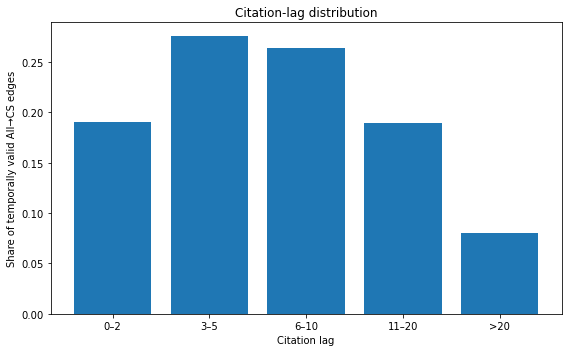

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/citation_lag_bucket_distribution.png')

In [19]:
valid_lag_edges = temporal_edges[has_both_years & temporal_edges['citation_lag'].ge(0)].copy()
lag_bins = [-0.1, 2, 5, 10, 20, np.inf]
lag_labels = ['0–2', '3–5', '6–10', '11–20', '>20']
valid_lag_edges['lag_bucket'] = pd.cut(valid_lag_edges['citation_lag'], bins=lag_bins, labels=lag_labels, include_lowest=True)
lag_bucket_summary = valid_lag_edges['lag_bucket'].value_counts(sort=False).reindex(lag_labels).rename('n_edges').to_frame()
lag_bucket_summary['share'] = lag_bucket_summary['n_edges'] / lag_bucket_summary['n_edges'].sum()
display(lag_bucket_summary)
save_table(lag_bucket_summary, 'citation_lag_bucket_distribution.csv')
plt.figure(figsize=(8, 5))
plt.bar(lag_bucket_summary.index.astype(str), lag_bucket_summary['share'])
plt.xlabel('Citation lag')
plt.ylabel('Share of temporally valid All→CS edges')
plt.title('Citation-lag distribution')
save_figure('citation_lag_bucket_distribution.png')

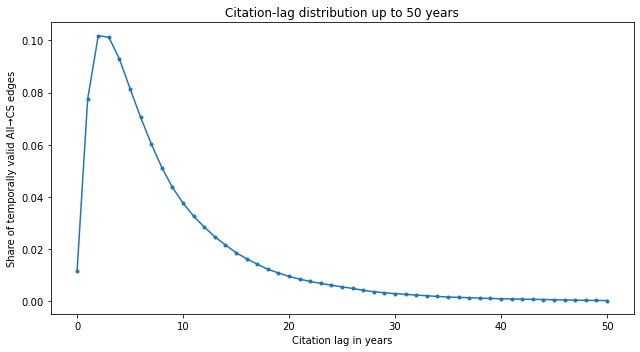

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/citation_lag_exact_up_to_50_years.png')

In [20]:
lag_distribution = valid_lag_edges['citation_lag'].value_counts().sort_index().rename('n_edges').to_frame()
lag_distribution['share'] = lag_distribution['n_edges'] / lag_distribution['n_edges'].sum()
save_table(lag_distribution, 'citation_lag_exact_distribution.csv')
lag_plot = lag_distribution.loc[lag_distribution.index <= 50]
plt.figure(figsize=(9, 5))
plt.plot(lag_plot.index, lag_plot['share'], marker='o', markersize=3)
plt.xlabel('Citation lag in years')
plt.ylabel('Share of temporally valid All→CS edges')
plt.title('Citation-lag distribution up to 50 years')
save_figure('citation_lag_exact_up_to_50_years.png')

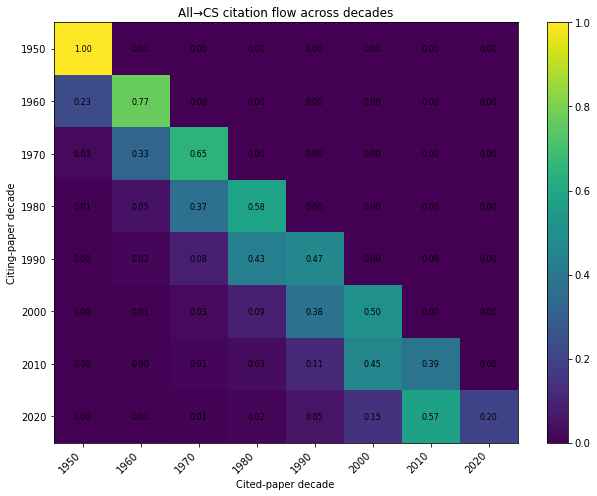

In [21]:
decade_valid = temporal_edges[temporal_edges['citing_decade'].notna() & temporal_edges['cited_decade'].notna()].copy()
decade_flow_counts = pd.crosstab(decade_valid['citing_decade'], decade_valid['cited_decade'])
decade_flow_counts = decade_flow_counts.sort_index().sort_index(axis=1)
decade_flow_row_normalized = decade_flow_counts.div(decade_flow_counts.sum(axis=1), axis=0).fillna(0)
save_table(decade_flow_counts, 'citation_flow_decade_counts.csv')
save_table(decade_flow_row_normalized, 'citation_flow_decade_row_normalized.csv')
heatmap_from_matrix(decade_flow_row_normalized, title='All→CS citation flow across decades', xlabel='Cited-paper decade', ylabel='Citing-paper decade', filename='citation_flow_decades_row_normalized.png')

In [22]:
same_decade_indicator = decade_valid['citing_decade'].eq(decade_valid['cited_decade'])
same_decade_by_citing_decade = decade_valid.assign(same_decade=same_decade_indicator).groupby('citing_decade')['same_decade'].agg(['mean', 'count']).rename(columns={'mean': 'same_decade_share', 'count': 'n_edges'})
same_decade_overall = pd.Series({'same_decade_share': same_decade_indicator.mean(), 'n_edges_with_both_decades': len(decade_valid)})
display(same_decade_overall.to_frame('value'))
display(same_decade_by_citing_decade)
save_table(same_decade_overall.to_frame('value'), 'same_decade_citation_share_overall.csv')
save_table(same_decade_by_citing_decade, 'same_decade_citation_share_by_citing_decade.csv')

,value
same_decade_share,3.576101e-01
n_edges_with_both_decades,1.160142e+07


,same_decade_share,n_edges
citing_decade,,
1950,1.0,411
1960,0.766033,7578
1970,0.646629,41755
1980,0.580401,163332
1990,0.466776,593132
2000,0.50222,2080214
2010,0.385136,5172983
2020,0.19957,3542011


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/same_decade_citation_share_by_citing_decade.csv')

In [23]:
del temporal_edges, valid_lag_edges, decade_valid
gc.collect()

100428

## 5.5.2 Citation Flows across Taxonomy Levels

,n_edges,n_valid_edges,metadata_coverage,same_taxonomy_share_among_valid
field,11601416.0,11601416.0,1.0,0.811447
subfield,11601416.0,11601416.0,1.0,0.589847
topic,11601416.0,11601416.0,1.0,0.431350


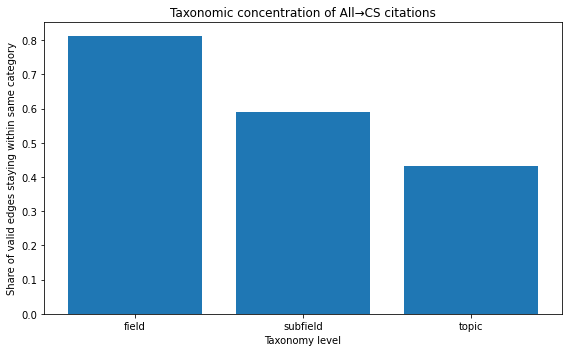

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/taxonomy_same_category_share.png')

In [24]:
def taxonomy_match_diagnostic(edges, metadata, column):
    mapping = metadata.set_index('id')[column]
    citing_value = edges['citing'].map(mapping)
    cited_value = edges['cited'].map(mapping)
    valid = citing_value.notna() & cited_value.notna()
    same = citing_value.eq(cited_value)
    summary = pd.Series({'n_edges': len(edges), 'n_valid_edges': int(valid.sum()), 'metadata_coverage': valid.mean(), 'same_taxonomy_share_among_valid': same[valid].mean()})
    return (summary, valid.to_numpy(), same.fillna(False).to_numpy())
taxonomy_rows = {}
taxonomy_arrays = {}
for column, label in [('primary_field', 'field'), ('primary_subfield', 'subfield'), ('primary_topic_name', 'topic')]:
    summary, valid, same = taxonomy_match_diagnostic(edges_all_to_cs, papers, column)
    taxonomy_rows[label] = summary
    taxonomy_arrays[label] = {'valid': valid, 'same': same}
taxonomy_match_summary = pd.DataFrame(taxonomy_rows).T
display(taxonomy_match_summary)
save_table(taxonomy_match_summary, 'taxonomy_match_summary_all_to_cs.csv')
plt.figure(figsize=(8, 5))
plt.bar(taxonomy_match_summary.index, taxonomy_match_summary['same_taxonomy_share_among_valid'])
plt.xlabel('Taxonomy level')
plt.ylabel('Share of valid edges staying within same category')
plt.title('Taxonomic concentration of All→CS citations')
save_figure('taxonomy_same_category_share.png')

,n_edges,share_all_edges,share_among_classified
Missing taxonomy,0,0.000000,NaN
Same topic,5004276,0.431350,0.431350
"Cross-topic, same subfield",1838783,0.158496,0.158496
"Cross-subfield, same field",2570873,0.221600,0.221600
Cross-field,2187484,0.188553,0.188553


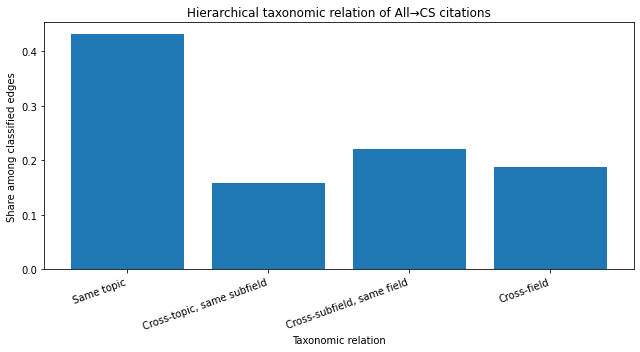

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/taxonomy_hierarchical_relation_distribution.png')

In [25]:
valid_field = taxonomy_arrays['field']['valid']
same_field = taxonomy_arrays['field']['same']
valid_subfield = taxonomy_arrays['subfield']['valid']
same_subfield = taxonomy_arrays['subfield']['same']
valid_topic = taxonomy_arrays['topic']['valid']
same_topic = taxonomy_arrays['topic']['same']
relation_code = np.full(len(edges_all_to_cs), -1, dtype=np.int8)
relation_code[valid_topic & valid_subfield & valid_field & same_topic] = 0
relation_code[valid_topic & valid_subfield & valid_field & ~same_topic & same_subfield] = 1
relation_code[valid_subfield & valid_field & ~same_subfield & same_field] = 2
relation_code[valid_field & ~same_field] = 3
relation_labels = {-1: 'Missing taxonomy', 0: 'Same topic', 1: 'Cross-topic, same subfield', 2: 'Cross-subfield, same field', 3: 'Cross-field'}
taxonomy_relation = pd.Series(relation_code).map(relation_labels)
taxonomy_relation_summary = taxonomy_relation.value_counts().reindex(list(relation_labels.values()), fill_value=0).rename('n_edges').to_frame()
taxonomy_relation_summary['share_all_edges'] = taxonomy_relation_summary['n_edges'] / taxonomy_relation_summary['n_edges'].sum()
known_relation_mask = taxonomy_relation.ne('Missing taxonomy')
taxonomy_relation_summary['share_among_classified'] = taxonomy_relation_summary['n_edges'] / taxonomy_relation[known_relation_mask].shape[0]
taxonomy_relation_summary.loc['Missing taxonomy', 'share_among_classified'] = np.nan
display(taxonomy_relation_summary)
save_table(taxonomy_relation_summary, 'taxonomy_hierarchical_relation_summary.csv')
plot_relations = taxonomy_relation_summary.drop(index='Missing taxonomy')
plt.figure(figsize=(9, 5))
plt.bar(plot_relations.index, plot_relations['share_among_classified'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('Share among classified edges')
plt.xlabel('Taxonomic relation')
plt.title('Hierarchical taxonomic relation of All→CS citations')
save_figure('taxonomy_hierarchical_relation_distribution.png')

In [26]:
del taxonomy_arrays, relation_code, taxonomy_relation
gc.collect()

5609

## 5.5.3 Gender-to-Gender Citation Flow Patterns

In [27]:
gender_map = papers.set_index('id')['first_last_cat']

def gender_flow(edges, slice_name):
    citing_gender = edges['citing'].map(gender_map)
    cited_gender = edges['cited'].map(gender_map)
    valid = citing_gender.isin(GENDER_CATEGORIES) & cited_gender.isin(GENDER_CATEGORIES)
    coverage = pd.Series({'citation_slice': slice_name, 'n_edges': len(edges), 'n_edges_known_gender_both_sides': int(valid.sum()), 'known_gender_both_sides_share': valid.mean()})
    counts = pd.crosstab(citing_gender[valid], cited_gender[valid]).reindex(index=GENDER_CATEGORIES, columns=GENDER_CATEGORIES, fill_value=0)
    row_normalized = counts.div(counts.sum(axis=1), axis=0).fillna(0)
    return (coverage, counts, row_normalized)
gender_coverage_all, gender_counts_all, gender_norm_all = gender_flow(edges_all_to_cs, 'All→CS')
gender_coverage_cs, gender_counts_cs, gender_norm_cs = gender_flow(edges_cs_to_cs, 'CS→CS')
gender_flow_coverage = pd.DataFrame([gender_coverage_all, gender_coverage_cs]).set_index('citation_slice')
display(gender_flow_coverage)
display(gender_norm_all)
display(gender_norm_cs)
save_table(gender_flow_coverage, 'gender_flow_coverage.csv')
save_table(gender_counts_all, 'gender_flow_counts_all_to_cs.csv')
save_table(gender_norm_all, 'gender_flow_row_normalized_all_to_cs.csv')
save_table(gender_counts_cs, 'gender_flow_counts_cs_to_cs.csv')
save_table(gender_norm_cs, 'gender_flow_row_normalized_cs_to_cs.csv')

,n_edges,n_edges_known_gender_both_sides,known_gender_both_sides_share
citation_slice,,,
All→CS,11601416,5948956,0.512778
CS→CS,9413932,4812158,0.511174


cited,MM,MW,WM,WW
citing,,,,
MM,0.815003,0.069175,0.085008,0.030814
MW,0.775211,0.081019,0.102970,0.040801
WM,0.769693,0.080957,0.107817,0.041534
WW,0.729658,0.086634,0.115849,0.067859


cited,MM,MW,WM,WW
citing,,,,
MM,0.813165,0.070566,0.085630,0.030639
MW,0.774066,0.082965,0.103310,0.039660
WM,0.769003,0.082284,0.108094,0.040618
WW,0.735405,0.086851,0.114973,0.062771


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/gender_flow_row_normalized_cs_to_cs.csv')

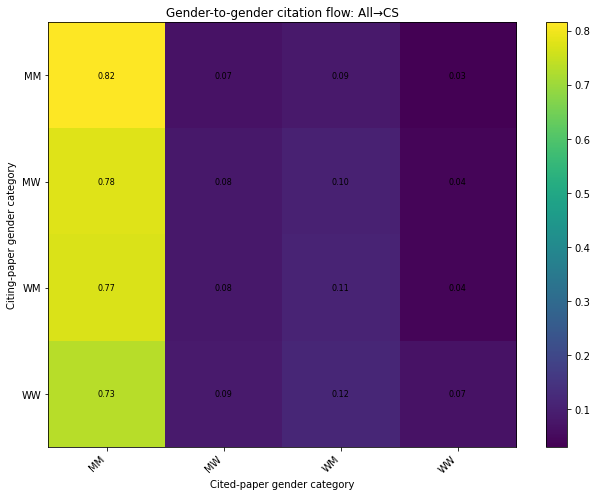

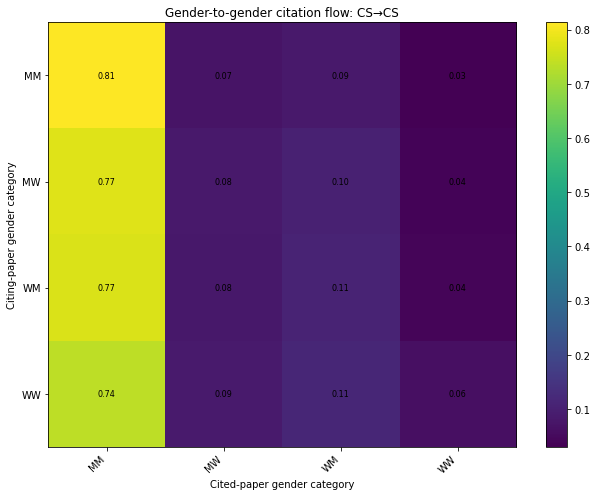

In [28]:
heatmap_from_matrix(gender_norm_all, title='Gender-to-gender citation flow: All→CS', xlabel='Cited-paper gender category', ylabel='Citing-paper gender category', filename='gender_flow_all_to_cs_row_normalized.png')
heatmap_from_matrix(gender_norm_cs, title='Gender-to-gender citation flow: CS→CS', xlabel='Cited-paper gender category', ylabel='Citing-paper gender category', filename='gender_flow_cs_to_cs_row_normalized.png')

# 5.6 Citation-Derived Network Diagnostics
## 5.6.1 Coverage and Sparsity across Network Representations

In [29]:
def network_nodes(edges):
    left = pd.Index(edges['paper_i'].unique())
    right = pd.Index(edges['paper_j'].unique())
    return left.union(right)
direct_nodes = pd.Index(edges_final['citing'].unique()).union(pd.Index(edges_final['cited'].unique()))
bib_nodes = network_nodes(bib_edges)
cocit_nodes = network_nodes(cocit_edges)
paper_ids = papers['id']
cs_ids = cs_papers['id']
known_cs_ids = cs_known['paper_id']
representation_rows = []
for name, nodes, n_edges_rep, directed in [('Direct citation', direct_nodes, len(edges_final), True), ('Bibliographic coupling', bib_nodes, len(bib_edges), False), ('Co-citation', cocit_nodes, len(cocit_edges), False)]:
    n_nodes_rep = len(nodes)
    possible_edges = n_nodes_rep * (n_nodes_rep - 1) if directed else n_nodes_rep * (n_nodes_rep - 1) / 2
    representation_rows.append({'representation': name, 'n_nodes': n_nodes_rep, 'n_edges': n_edges_rep, 'density': n_edges_rep / possible_edges if possible_edges > 0 else np.nan, 'coverage_all_final_papers': paper_ids.isin(nodes).mean(), 'coverage_cs_papers': cs_ids.isin(nodes).mean(), 'coverage_known_gender_cs_papers': known_cs_ids.isin(nodes).mean()})
network_coverage_summary = pd.DataFrame(representation_rows).set_index('representation')
display(network_coverage_summary)
save_table(network_coverage_summary, 'network_representation_coverage_and_sparsity.csv')

,n_nodes,n_edges,density,coverage_all_final_papers,coverage_cs_papers,coverage_known_gender_cs_papers
representation,,,,,,
Direct citation,3026412,18904534,0.000002,1.000000,1.000000,1.000000
Bibliographic coupling,937161,3934046,0.000009,0.309661,0.385177,0.361071
Co-citation,188119,232065,0.000013,0.062159,0.075569,0.078344


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/network_representation_coverage_and_sparsity.csv')

,representation,gender_cat,n_known_gender_cs_papers,n_covered,coverage_share
0,Bibliographic coupling,MM,790617,285905,0.361623
1,Bibliographic coupling,MW,97399,36119,0.370835
2,Bibliographic coupling,WM,137756,51791,0.375962
3,Bibliographic coupling,WW,55591,16634,0.299221
4,Co-citation,MM,790617,66617,0.084260
5,Co-citation,MW,97399,6727,0.069066
6,Co-citation,WM,137756,8435,0.061231
7,Co-citation,WW,55591,2939,0.052868


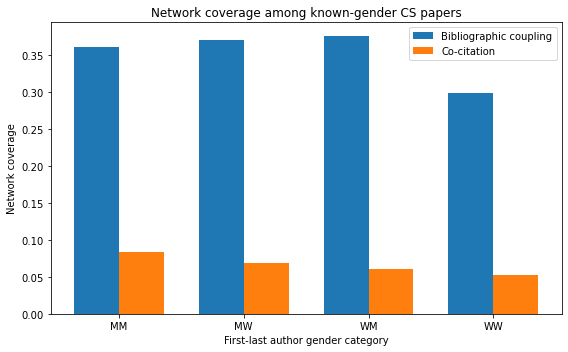

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/network_coverage_by_gender.png')

In [30]:
coverage_by_gender_rows = []
for representation, nodes in [('Bibliographic coupling', bib_nodes), ('Co-citation', cocit_nodes)]:
    for gender in GENDER_CATEGORIES:
        ids = cs_known.loc[cs_known['gender_cat'].eq(gender), 'paper_id']
        coverage_by_gender_rows.append({'representation': representation, 'gender_cat': gender, 'n_known_gender_cs_papers': len(ids), 'n_covered': int(ids.isin(nodes).sum()), 'coverage_share': ids.isin(nodes).mean()})
network_coverage_by_gender = pd.DataFrame(coverage_by_gender_rows)
display(network_coverage_by_gender)
save_table(network_coverage_by_gender, 'network_coverage_by_gender.csv', index=False)
x = np.arange(len(GENDER_CATEGORIES))
width = 0.36
bib_cov = network_coverage_by_gender[network_coverage_by_gender['representation'].eq('Bibliographic coupling')].set_index('gender_cat').reindex(GENDER_CATEGORIES)['coverage_share']
cocit_cov = network_coverage_by_gender[network_coverage_by_gender['representation'].eq('Co-citation')].set_index('gender_cat').reindex(GENDER_CATEGORIES)['coverage_share']
plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, bib_cov, width, label='Bibliographic coupling')
plt.bar(x + width / 2, cocit_cov, width, label='Co-citation')
plt.xticks(x, GENDER_CATEGORIES)
plt.ylabel('Network coverage')
plt.xlabel('First-last author gender category')
plt.title('Network coverage among known-gender CS papers')
plt.legend()
save_figure('network_coverage_by_gender.png')

,decade,coverage_share,n_known_gender_cs_papers,representation
0,1950,0.005906,508,Bibliographic coupling
1,1960,0.071095,2996,Bibliographic coupling
2,1970,0.134135,12137,Bibliographic coupling
3,1980,0.225596,36029,Bibliographic coupling
4,1990,0.299964,95488,Bibliographic coupling
5,2000,0.341445,271739,Bibliographic coupling
6,2010,0.401199,449206,Bibliographic coupling
7,2020,0.369638,213260,Bibliographic coupling
8,1950,0.133858,508,Co-citation
9,1960,0.168892,2996,Co-citation


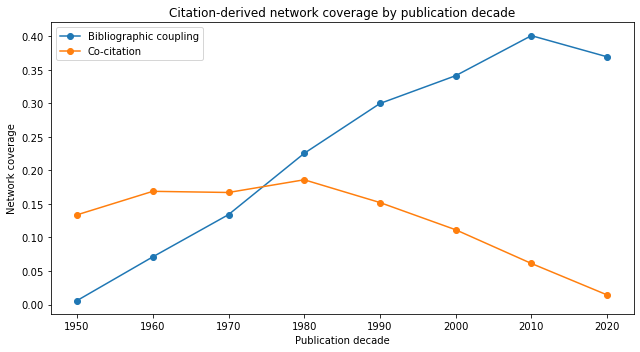

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/network_coverage_by_decade.png')

In [31]:
coverage_by_decade_rows = []
for representation, nodes in [('Bibliographic coupling', bib_nodes), ('Co-citation', cocit_nodes)]:
    temp = cs_known[['paper_id', 'decade']].copy()
    temp['covered'] = temp['paper_id'].isin(nodes)
    g = temp.dropna(subset=['decade']).groupby('decade')['covered'].agg(['mean', 'count']).reset_index().rename(columns={'mean': 'coverage_share', 'count': 'n_known_gender_cs_papers'})
    g['representation'] = representation
    coverage_by_decade_rows.append(g)
network_coverage_by_decade = pd.concat(coverage_by_decade_rows, ignore_index=True)
display(network_coverage_by_decade)
save_table(network_coverage_by_decade, 'network_coverage_by_decade.csv', index=False)
plt.figure(figsize=(9, 5))
for representation in ['Bibliographic coupling', 'Co-citation']:
    g = network_coverage_by_decade[network_coverage_by_decade['representation'].eq(representation)].sort_values('decade')
    plt.plot(g['decade'], g['coverage_share'], marker='o', label=representation)
plt.xlabel('Publication decade')
plt.ylabel('Network coverage')
plt.title('Citation-derived network coverage by publication decade')
plt.legend()
save_figure('network_coverage_by_decade.png')

## 5.6.2 Co-Citation and Bibliographic-Coupling Weight Distributions

In [32]:
def network_weight_summary(edges):
    q = edges['weight'].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0])
    out = pd.DataFrame({'weight': q})
    out['jaccard'] = edges['jaccard'].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0])
    out.index.name = 'quantile'
    return out
bib_weight_summary = network_weight_summary(bib_edges)
cocit_weight_summary = network_weight_summary(cocit_edges)
display(bib_weight_summary)
display(cocit_weight_summary)
save_table(bib_weight_summary, 'bibliographic_coupling_weight_quantiles.csv')
save_table(cocit_weight_summary, 'cocitation_weight_quantiles.csv')

,weight,jaccard
quantile,,
0.000,3.0,0.011450
0.250,3.0,0.166667
0.500,4.0,0.222222
0.750,5.0,0.300000
0.900,6.0,0.375000
0.950,8.0,0.454545
0.990,11.0,0.750000
0.999,18.0,1.000000
1.000,195.0,1.000000


,weight,jaccard
quantile,,
0.000,5.000,0.001199
0.250,6.000,0.092105
0.500,8.000,0.148148
0.750,12.000,0.227273
0.900,23.000,0.333333
0.950,36.000,0.421053
0.990,94.000,0.625000
0.999,324.936,0.875000
1.000,7178.000,1.000000


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/cocitation_weight_quantiles.csv')

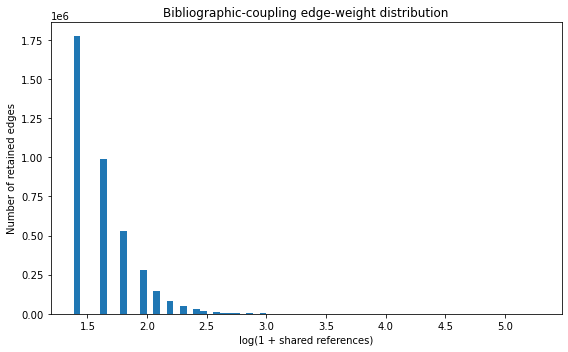

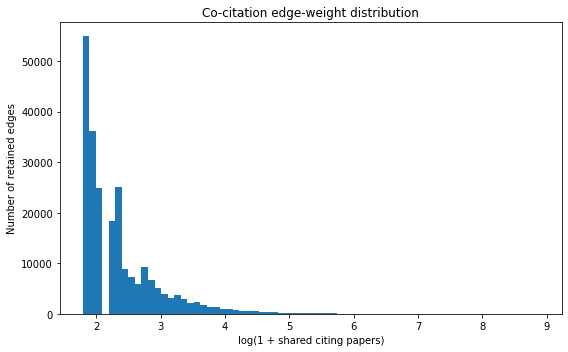

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/cocitation_weight_distribution.png')

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(bib_edges['weight']), bins=70)
plt.xlabel('log(1 + shared references)')
plt.ylabel('Number of retained edges')
plt.title('Bibliographic-coupling edge-weight distribution')
save_figure('bibliographic_coupling_weight_distribution.png')
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(cocit_edges['weight']), bins=70)
plt.xlabel('log(1 + shared citing papers)')
plt.ylabel('Number of retained edges')
plt.title('Co-citation edge-weight distribution')
save_figure('cocitation_weight_distribution.png')

In [34]:
network_weight_jaccard_diagnostics = []
for name, edges in [('Bibliographic coupling', bib_edges), ('Co-citation', cocit_edges)]:
    row = {'representation': name, 'n_edges': len(edges), 'mean_weight': edges['weight'].mean(), 'median_weight': edges['weight'].median(), 'max_weight': edges['weight'].max()}
    valid = edges[['weight', 'jaccard']].dropna()
    if len(valid) > 500000:
        valid = valid.sample(n=500000, random_state=RANDOM_STATE)
    row['mean_jaccard'] = valid['jaccard'].mean()
    row['median_jaccard'] = valid['jaccard'].median()
    row['weight_jaccard_spearman'] = valid[['weight', 'jaccard']].corr(method='spearman').iloc[0, 1]
    network_weight_jaccard_diagnostics.append(row)
network_weight_jaccard_diagnostics = pd.DataFrame(network_weight_jaccard_diagnostics).set_index('representation')
display(network_weight_jaccard_diagnostics)
save_table(network_weight_jaccard_diagnostics, 'network_weight_jaccard_diagnostics.csv')

,n_edges,mean_weight,median_weight,max_weight,mean_jaccard,median_jaccard,weight_jaccard_spearman
representation,,,,,,,
Bibliographic coupling,3934046,4.252787,4.0,195,0.246634,0.222222,0.344742
Co-citation,232065,13.272695,8.0,7178,0.178043,0.148148,0.069744


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/network_weight_jaccard_diagnostics.csv')

## 5.6.3 Network Degree and Strength by Gender Category

In [35]:
bib_features = network_node_features(bib_edges, prefix='bib')
cocit_features = network_node_features(cocit_edges, prefix='cocit')
display(bib_features.head())
display(cocit_features.head())
save_table(bib_features, 'bibliographic_coupling_node_features.csv', index=False)
save_table(cocit_features, 'cocitation_node_features.csv', index=False)

,paper_id,bib_degree,bib_strength,bib_mean_weight,bib_max_weight
0,W1985697265,1,195,195.000000,195
1,W4293464704,3,433,144.333333,146
2,W4293464697,3,431,143.666667,145
3,W4293464712,3,433,144.333333,146
4,W4210976388,1,115,115.000000,115


,paper_id,cocit_degree,cocit_strength,cocit_mean_weight,cocit_max_weight
0,W2108598243,2,9865,4932.5,7178
1,W2097117768,4,8254,2063.5,4466
2,W2112796928,6,5262,877.0,2932
3,W2570343428,4,4914,1228.5,2502
4,W1996360405,2,3203,1601.5,2372


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/cocitation_node_features.csv')

In [36]:
known_gender_map = cs_known.set_index('paper_id')['gender_cat']
bib_features['gender_cat'] = bib_features['paper_id'].map(known_gender_map)
cocit_features['gender_cat'] = cocit_features['paper_id'].map(known_gender_map)
bib_known = bib_features[bib_features['gender_cat'].isin(GENDER_CATEGORIES)].copy()
cocit_known = cocit_features[cocit_features['gender_cat'].isin(GENDER_CATEGORIES)].copy()

def feature_summary_by_gender(df, feature_cols):
    frames = []
    for feature in feature_cols:
        summary = df.groupby('gender_cat')[feature].agg(n='count', mean='mean', median='median', p90=lambda s: s.quantile(0.9), p95=lambda s: s.quantile(0.95), p99=lambda s: s.quantile(0.99), max='max').reindex(GENDER_CATEGORIES)
        summary['feature'] = feature
        frames.append(summary.reset_index())
    return pd.concat(frames, ignore_index=True)
bib_feature_cols = ['bib_degree', 'bib_strength', 'bib_mean_weight', 'bib_max_weight']
cocit_feature_cols = ['cocit_degree', 'cocit_strength', 'cocit_mean_weight', 'cocit_max_weight']
bib_gender_summary = feature_summary_by_gender(bib_known, bib_feature_cols)
cocit_gender_summary = feature_summary_by_gender(cocit_known, cocit_feature_cols)
display(bib_gender_summary)
display(cocit_gender_summary)
save_table(bib_gender_summary, 'bibliographic_coupling_features_by_gender.csv', index=False)
save_table(cocit_gender_summary, 'cocitation_features_by_gender.csv', index=False)

,gender_cat,n,mean,median,p90,p95,p99,max,feature
0,MM,285905,8.369490,4.000000,22.000000,30.000000,54.000000,486.0,bib_degree
1,MW,36119,8.533514,4.000000,23.000000,30.000000,53.820000,350.0,bib_degree
2,WM,51791,8.502887,4.000000,23.000000,30.000000,55.000000,302.0,bib_degree
3,WW,16634,7.471805,3.000000,21.000000,27.000000,49.000000,170.0,bib_degree
4,MM,285905,35.665032,15.000000,91.000000,131.000000,259.000000,2652.0,bib_strength
5,MW,36119,36.613444,15.000000,93.000000,134.000000,267.000000,1738.0,bib_strength
6,WM,51791,36.335174,15.000000,94.000000,132.000000,270.000000,1304.0,bib_strength
7,WW,16634,31.806601,13.000000,83.000000,118.000000,239.000000,925.0,bib_strength
8,MM,285905,4.356085,3.833333,6.200000,7.750000,12.000000,195.0,bib_mean_weight
9,MW,36119,4.334895,3.826087,6.111111,7.500000,12.000000,195.0,bib_mean_weight


,gender_cat,n,mean,median,p90,p95,p99,max,feature
0,MM,66617,2.528829,2.0,5.000000,7.000000,12.000,29.0,cocit_degree
1,MW,6727,2.538279,2.0,5.000000,7.000000,12.000,25.0,cocit_degree
2,WM,8435,2.514167,2.0,5.000000,7.000000,12.000,28.0,cocit_degree
3,WW,2939,2.497448,2.0,5.000000,7.000000,11.620,20.0,cocit_degree
4,MM,66617,36.600312,13.0,75.000000,127.000000,375.840,10085.0,cocit_strength
5,MW,6727,36.377880,13.0,71.000000,126.000000,391.700,3936.0,cocit_strength
6,WM,8435,31.679668,12.0,68.000000,114.000000,321.320,1580.0,cocit_strength
7,WW,2939,30.213338,13.0,64.000000,104.000000,285.100,2530.0,cocit_strength
8,MM,66617,12.163311,7.0,19.000000,29.000000,79.200,7178.0,cocit_mean_weight
9,MW,6727,11.104493,7.0,18.000000,27.000000,64.870,804.0,cocit_mean_weight


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/cocitation_features_by_gender.csv')

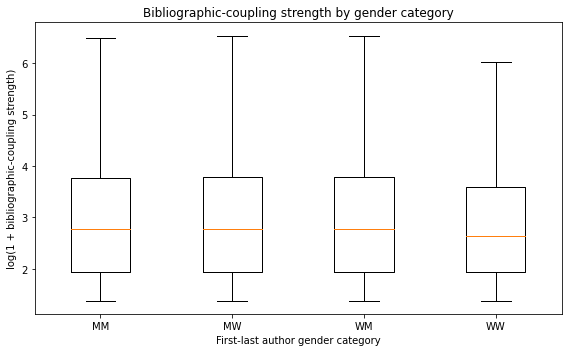

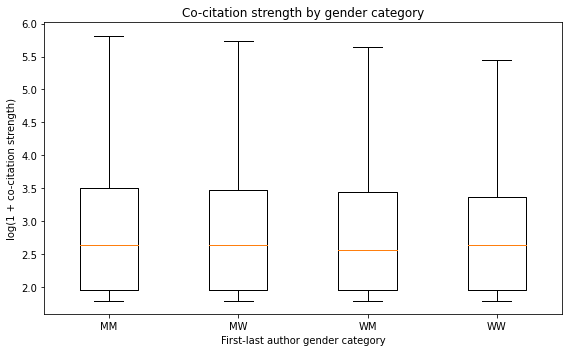

WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/figures/cocitation_strength_by_gender.png')

In [37]:
bib_plot = sampled_by_gender(bib_known[['gender_cat', 'bib_degree', 'bib_strength']])
cocit_plot = sampled_by_gender(cocit_known[['gender_cat', 'cocit_degree', 'cocit_strength']])
plt.figure(figsize=(8, 5))
plt.boxplot([np.log1p(bib_plot.loc[bib_plot['gender_cat'].eq(g), 'bib_strength']) for g in GENDER_CATEGORIES], labels=GENDER_CATEGORIES, showfliers=False)
plt.xlabel('First-last author gender category')
plt.ylabel('log(1 + bibliographic-coupling strength)')
plt.title('Bibliographic-coupling strength by gender category')
save_figure('bibliographic_coupling_strength_by_gender.png')
plt.figure(figsize=(8, 5))
plt.boxplot([np.log1p(cocit_plot.loc[cocit_plot['gender_cat'].eq(g), 'cocit_strength']) for g in GENDER_CATEGORIES], labels=GENDER_CATEGORIES, showfliers=False)
plt.xlabel('First-last author gender category')
plt.ylabel('log(1 + co-citation strength)')
plt.title('Co-citation strength by gender category')
save_figure('cocitation_strength_by_gender.png')

In [38]:
skew_rows = []
for representation, df, feature_cols in [('Bibliographic coupling', bib_known, bib_feature_cols), ('Co-citation', cocit_known, cocit_feature_cols)]:
    for feature in feature_cols:
        x = pd.to_numeric(df[feature], errors='coerce').dropna()
        skew_rows.append({'representation': representation, 'feature': feature, 'raw_skewness': x.skew(), 'log1p_skewness': np.log1p(x.clip(lower=0)).skew(), 'raw_median': x.median(), 'raw_p99': x.quantile(0.99), 'raw_max': x.max()})
network_feature_skewness = pd.DataFrame(skew_rows)
display(network_feature_skewness)
save_table(network_feature_skewness, 'network_feature_skewness_log1p_diagnostic.csv', index=False)

,representation,feature,raw_skewness,log1p_skewness,raw_median,raw_p99,raw_max
0,Bibliographic coupling,bib_degree,4.840699,0.649249,4.000000,54.0,486.0
1,Bibliographic coupling,bib_strength,5.946850,0.449004,15.000000,261.0,2652.0
2,Bibliographic coupling,bib_mean_weight,11.622467,1.740702,3.833333,12.0,195.0
3,Bibliographic coupling,bib_max_weight,4.508710,0.892048,5.000000,18.0,195.0
4,Co-citation,cocit_degree,2.673166,1.074780,2.000000,12.0,29.0
5,Co-citation,cocit_strength,29.358924,1.045212,13.000000,367.0,10085.0
6,Co-citation,cocit_mean_weight,94.663073,2.193146,7.000000,75.0,7178.0
7,Co-citation,cocit_max_weight,53.458592,1.774270,8.000000,137.0,7178.0


WindowsPath('c:/Users/blaze/OneDrive/Documents/GitHub/citation-gender-imbalance/outputs/05_network_eda/tables/network_feature_skewness_log1p_diagnostic.csv')

In [39]:
feature_correlations = {}
for representation, df, feature_cols in [('bibliographic_coupling', bib_known, bib_feature_cols), ('cocitation', cocit_known, cocit_feature_cols)]:
    sample = df[feature_cols].dropna()
    if len(sample) > 300000:
        sample = sample.sample(n=300000, random_state=RANDOM_STATE)
    corr = sample.corr(method='spearman')
    feature_correlations[representation] = corr
    display(corr)
    save_table(corr, f'{representation}_feature_spearman_correlations.csv')

,bib_degree,bib_strength,bib_mean_weight,bib_max_weight
bib_degree,1.000000,0.959245,0.083860,0.381166
bib_strength,0.959245,1.000000,0.331565,0.594414
bib_mean_weight,0.083860,0.331565,1.000000,0.890923
bib_max_weight,0.381166,0.594414,0.890923,1.000000


,cocit_degree,cocit_strength,cocit_mean_weight,cocit_max_weight
cocit_degree,1.000000,0.854321,0.407931,0.570660
cocit_strength,0.854321,1.000000,0.797265,0.890814
cocit_mean_weight,0.407931,0.797265,1.000000,0.971110
cocit_max_weight,0.570660,0.890814,0.971110,1.000000
